### Decision Tree Regression

While the Decision Tree is almost never used in the real world, it is the fundamental building block for more powerful and popular algorithms like Random Forests and XGBoost.

## Intuition

A Decision Tree tries to model one or more output values, given one or more input values.
Its structure is that of a Binary Tree, and at each non-leaf node it makes a decision based on an input value via a logical statement that can be either True or False.
Based on the decisions in each non-leaf node, it generates an output in the leaf nodes.

In particular, a Decision Tree Regressor tries to model a continuous variable, a real number indicating some quantity.
Let's take a look at a simple Decision Tree Regressor.

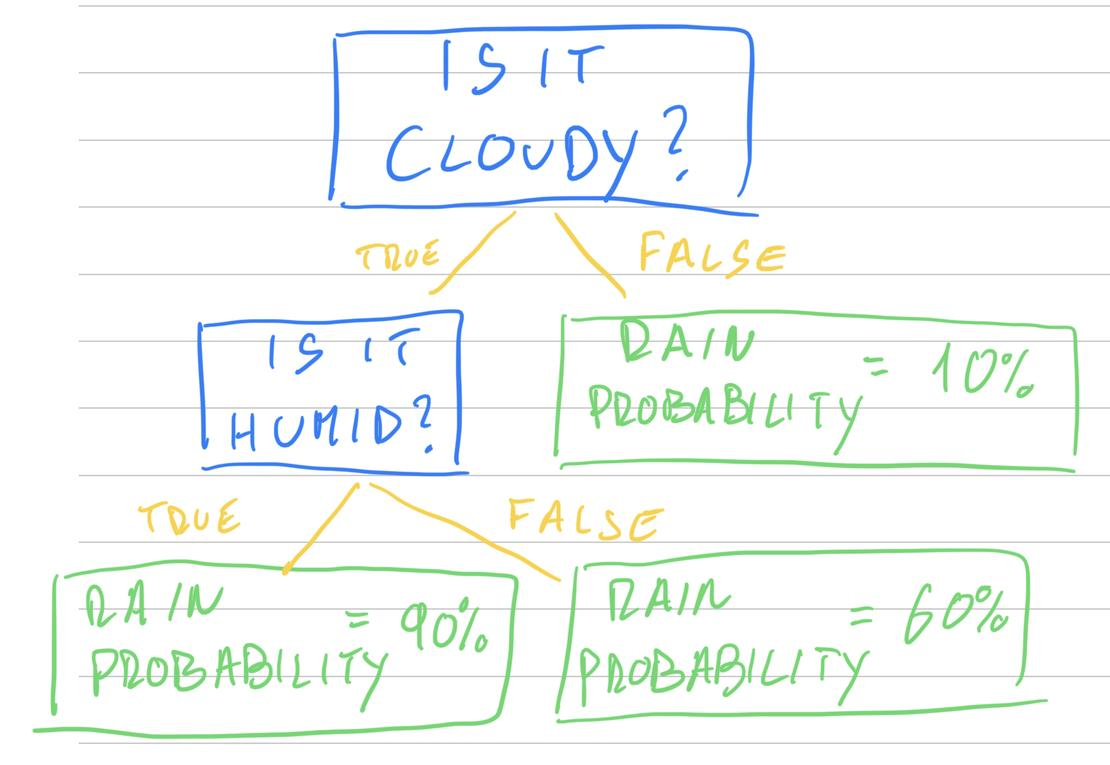

The Decision Tree Regressor above was constructed based on rules that we decided.
Let's see how to build a Decision Tree Regressor starting from a dataset.
We'll be using a very simplified version of the house prices dataset. We'll try to predict a house's selling price based on some input features.

Import

In [ ]:
import numpy as np  # linear algebra
import pandas as pd  # data processing

from sklearn.tree import DecisionTreeRegressor  # model

from matplotlib import pyplot as plt  # visualization
from sklearn.tree import plot_tree  # visualize tree

Dataset

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
def preprocess(df):
    cols_to_drop = [col for col in df.columns if col not in ['LotArea', 'SalePrice']]
    df['Pool'] = (df['PoolArea'] > 0).astype('int64')
    df['NewConstruction'] = (df['SaleType'] == 'New').astype('int64')
    df['SalePrice'] = df['SalePrice'] // 1000
    df = df.drop(columns=cols_to_drop)
    df = df[['NewConstruction', 'Pool', 'LotArea', 'SalePrice']]

    return df

In [ ]:
df = df.loc[df.index.isin([197, 810, 11, 18, 1449])]
df = preprocess(df)
df

<ipython-input-4-31b762370507>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Pool'] = (df['PoolArea'] > 0).astype('int64')
<ipython-input-4-31b762370507>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NewConstruction'] = (df['SaleType'] == 'New').astype('int64')
<ipython-input-4-31b762370507>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

,NewConstruction,Pool,LotArea,SalePrice
11,1,0,11924,345
18,0,0,13695,159
197,0,1,25419,235
810,0,1,10140,181
1449,0,0,1533,92


<a id="3"></a>
# ♻️ CART Algorithm

How do we determine the shape of our Decision Tree Regressor and which features to process in each node?
We do this by using the Classification And Regression Tree (CART) Algorithm.
Let's define it below.

For each node, until the number of samples to process within the node is greater than the minimum samples to split number:

1. Find each feature's best split. If there are  k distinct values within a numeric feature, the number of possible splits among them is  k−1.Find the split which minimizes the splitting criterion.
2. Among these best splits (which will be 1 for each feature), find the best. Once again, according to the splitting criterion.
3. Split the node according to the best split found above. This will create 2 new nodes. Repeat the process until the conditions defined above are not valid anymore.

<a id="4"></a>
# 🪓 Mean Squared Error | Splitting Criterion

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    The splitting criterion we'll be using to build our tree is the Mean Squared Error. Given a real output value $ y_i $ and a predicted output value $ \hat{y}_i $, where $ i $ iterates over the $ n $ samples, the Mean Squared Error $ MSE $ is defined as follows:
    $$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
</div>

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    So basically, we take the squared difference of our real outputs and our predicted outputs, sum them all up, and divide by the number of samples. <br>
    Our objective is to minimize the MSE in our leaf nodes. <br>
    In the best case scenario $ \hat{y}_i = y_i $ for each $ i $, which means that each prediction is equal to the real output, which in turn means $ MSE = 0 $.
</div>

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    In our House Prices example, $ y_i $ will be the house's real selling price, and $ \hat{y}_i $ will our tree's predicted selling price. <br>
    Now we can start building our Decision Tree Regressor.
</div>

<a id="5"></a>
# 🧱 Building the Tree

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    Now we have all we need to start building our tree, so let's go through the steps of the CART algorithm using our example dataset. <br>
</div>

In [ ]:
df

,NewConstruction,Pool,LotArea,SalePrice
11,1,0,11924,345
18,0,0,13695,159
197,0,1,25419,235
810,0,1,10140,181
1449,0,0,1533,92


<a id="5.1"></a>
## CART Step 1

Step 1 will be, for each feature, finding the value that splits our outputs into 2 groups of data, according to the  **MSE**
 .

For the NewConstruction and Pool features, there is only one possible split, since there are only 2 values in each feature.

The split value will be the mean of the 2 values. Since our 2 values are 0 and 1, our split will be at 0.5.

Once we've grouped our real  y^i
  into 2 groups, for each group, we calculate our prediction  y^i
  to be the mean of the values within the group.
Then, we calculate the  MSE
  using these 2  y^i
  as our predicted values.

Let's clarify this process below by looking at the NewConstruction feature.

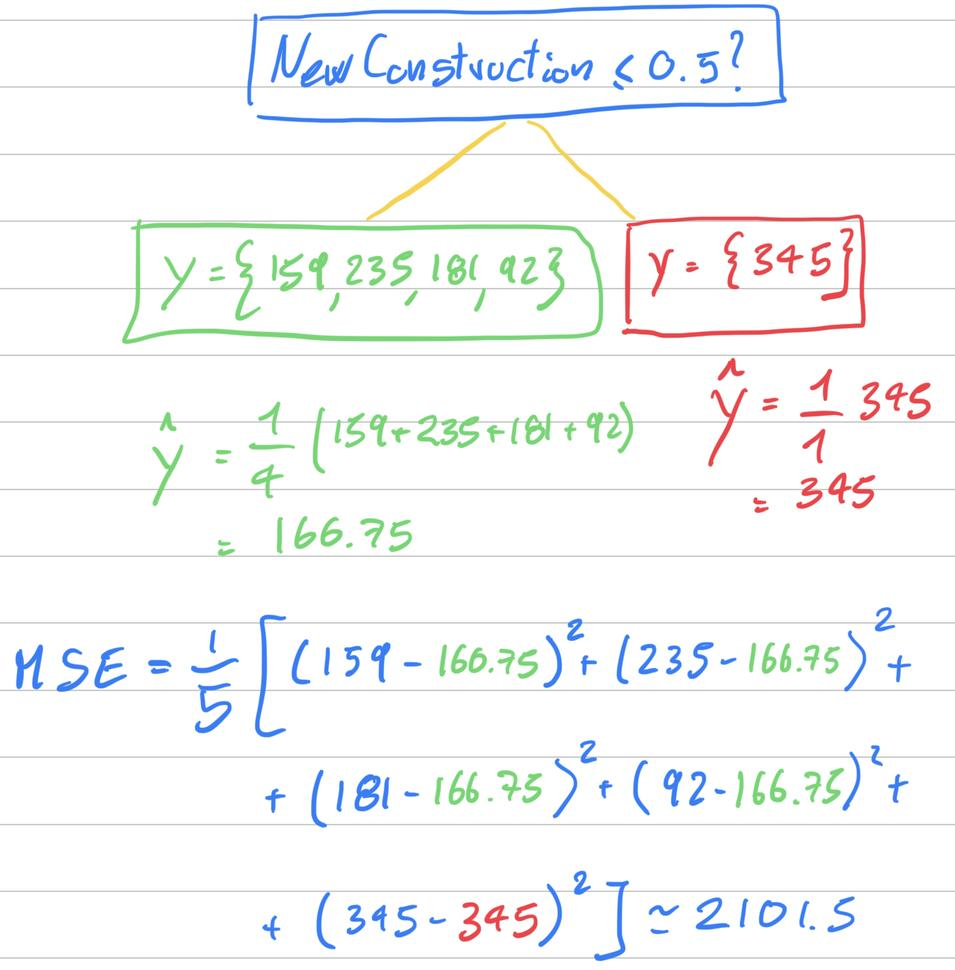

Since we can only split the NewConstruction feature one way, we have that the minimum  **MSE**
  for this feature is **2101.75**.

  **min(MSENewConstruction)=2101.75**




In [ ]:
df

,NewConstruction,Pool,LotArea,SalePrice
11,1,0,11924,345
18,0,0,13695,159
197,0,1,25419,235
810,0,1,10140,181
1449,0,0,1533,92


Let's also compute the  **MSE**
 , by hand, for the Pool feature, which can only be split one way, on **0.5.**

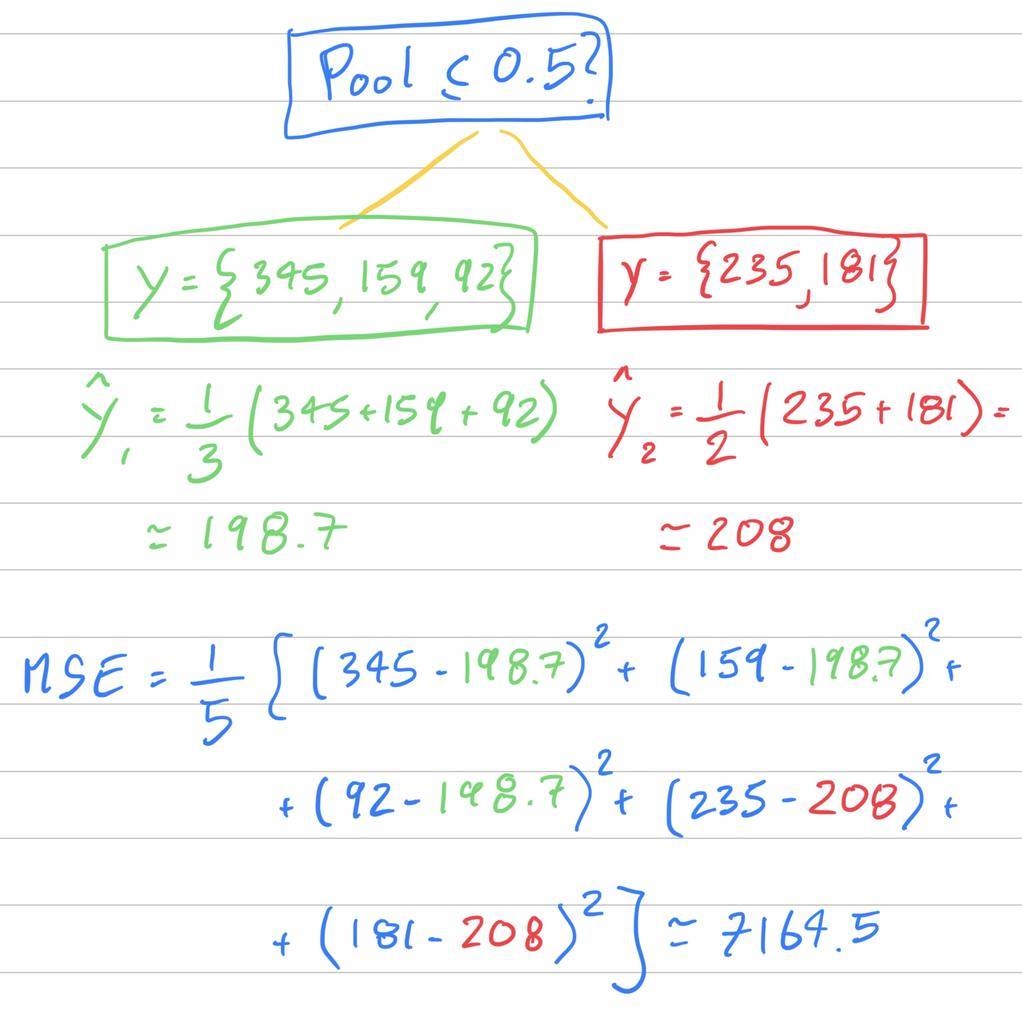

Since we can only split the Pool feature one way, we have that the **minimum  MSE**
  for this feature is 7164.5.
  
**min(MSEPool)=7164.5**

In [ ]:
df

,NewConstruction,Pool,LotArea,SalePrice
11,1,0,11924,345
18,0,0,13695,159
197,0,1,25419,235
810,0,1,10140,181
1449,0,0,1533,92


<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    For the LotArea, we have 5 distinct values, which means we have 4 ways to split the feature. <br>
    The values are, in sorted order: [1533, 10140, 11924, 13695, 25419]. <br>
    We calculate the 4 possible split values by taking the mean of each 2 adjacent data points. <br>
    Let's write some code to assist us in this task.
</div>

In [ ]:
def get_split_values(df, feature):
    distinct_values = sorted(df[feature].unique())

    split_values = []
    for i in range(1, len(distinct_values)):
        split_val = (distinct_values[i-1] + distinct_values[i]) / 2
        split_values.append(split_val)

    return split_values

In [ ]:
split_values = get_split_values(df, 'LotArea')
split_values

[5836.5, 11032.0, 12809.5, 19557.0]

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    Our possible split values for LotArea are [5836.5, 11032.0, 12809.5, 19557.0]. <br>
    This means that we will compute 4 MSEs for LotArea and pick the smallest one, to get the best split for LotArea. <br>
    Since the task is pretty time intensive by hand, let's write some code to assist us.
</div>

In [ ]:
# computing key split info given a feature and a split value
# this is the code implementation of what we did before by hand
def get_split_info(df, feature, split_val):
    df1 = df.loc[df[feature] <= split_val]
    df2 = df.loc[df[feature] > split_val]

    y1_values = df1['SalePrice'].values
    y1_pred = y1_values.mean()

    y2_values = df2['SalePrice'].values
    y2_pred = y2_values.mean()

    mse = 0
    for y1 in y1_values:
        mse += (y1 - y1_pred)**2

    for y2 in y2_values:
        mse += (y2 - y2_pred)**2

    n1 = len(y1_values)
    n2 = len(y2_values)
    n = n1 + n2

    mse /= n

    return {
        "split_value": split_val,
        "y1_pred": y1_pred,
        "n1": n1,
        "y2_pred": y2_pred,
        "n2": n2,
        "mse": mse
    }

In [ ]:
split_info = []
for split_val in split_values:
    split_info.append(get_split_info(df, 'LotArea', split_val))
split_df = pd.DataFrame(split_info)
split_df

,split_value,y1_pred,n1,y2_pred,n2,mse
0,5836.5,92.00,1,230.000000,4,4138.400000
1,11032.0,136.50,2,246.333333,3,4290.233333
2,12809.5,206.00,3,197.000000,2,7166.000000
3,19557.0,194.25,4,235.000000,1,6919.750000


In [ ]:
split_df.loc[split_df['mse'] == split_df['mse'].min()]

,split_value,y1_pred,n1,y2_pred,n2,mse
0,5836.5,92.0,1,230.0,4,4138.4


As we can see, out of our 4 split values for LotArea, the one with smallest MSE is the split at **5836.5**, with **MSE** of **4138.4.**

**min(MSELotArea)=4138.4**

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    And with this, we are done with step 1 of the CART Algorithm, for the first node in our Decision Tree Regressor.
</div>

<a id="5.2"></a>
## CART Step 2

For our 3 input features, we've calculated the best split according to the MSE.

**min(MSENewConstruction)=2101.75**

**min(MSEPool)=7164.5**

**min(MSELotArea)=4138.4**

For Step 2, we find the smallest MSE of these, and so we pick the best feature, with the best split.

Our best feature is NewConstruction, with a split value of 0.5, and an MSE of:

**MSEbest=2101.75**

<a id="5.3"></a>
## CART Step 3

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    And now for Step 3, our final step in our first iteration, we split the data according to the best split, thereby creating 2 new nodes, in which we can repeat the CART steps.
</div>

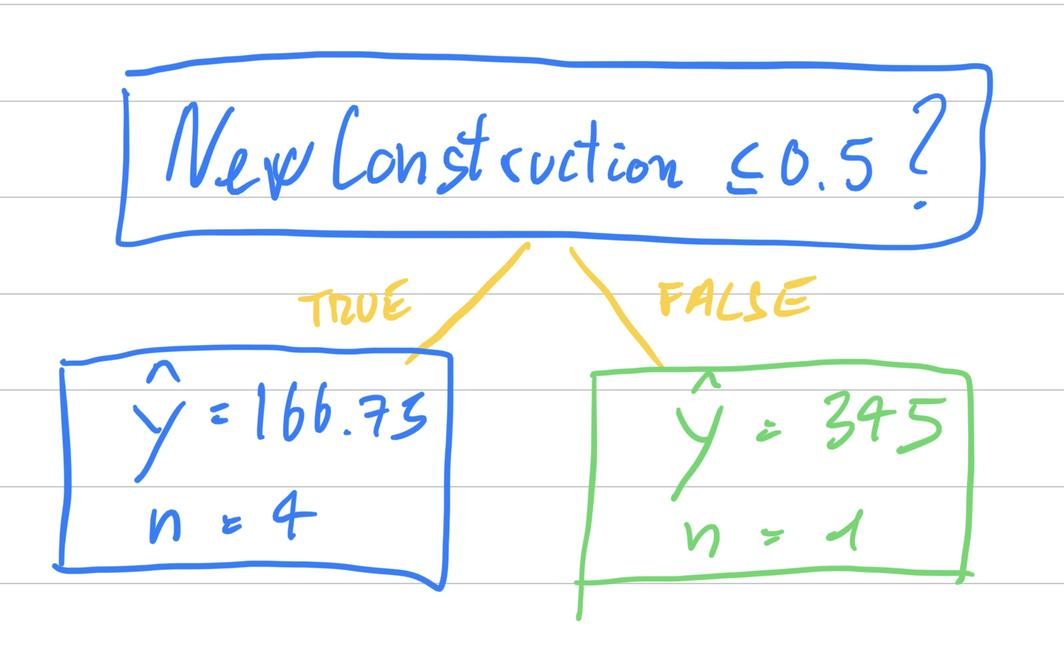

<a id="5.4"></a>
## Minimum Samples Split

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    How do we decide when to stop splitting a node, and keep a node's prediction as the mean of the samples within the node? <br>
    We do that by setting a Minimum Samples Split, which is the minimum number of samples within a node to start the split finding steps 1 through 3. <br>
    Let's say in our case, we set the Minimum Samples Split to 4. That means that we can't split the right node anymore, but we can split the left node.
</div>

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    Let's go through steps 1 through 3 in our left node, using the code we defined above.
</div>

In [ ]:
df_left = df.loc[df['NewConstruction'] < 0.5]
df_left

,NewConstruction,Pool,LotArea,SalePrice
18,0,0,13695,159
197,0,1,25419,235
810,0,1,10140,181
1449,0,0,1533,92


In [ ]:
split_values = get_split_values(df_left, 'Pool')
split_info = []
for split_val in split_values:
    split_info.append(get_split_info(df_left, 'Pool', split_val))
split_df = pd.DataFrame(split_info)
split_df

,split_value,y1_pred,n1,y2_pred,n2,mse
0,0.5,125.5,2,208.0,2,925.625


In [ ]:
split_values = get_split_values(df_left, 'LotArea')
split_info = []
for split_val in split_values:
    split_info.append(get_split_info(df_left, 'LotArea', split_val))
split_df = pd.DataFrame(split_info)
split_df

,split_value,y1_pred,n1,y2_pred,n2,mse
0,5836.5,92.0,1,191.666667,3,764.666667
1,11917.5,136.5,2,197.000000,2,1712.125000
2,19557.0,144.0,3,235.000000,1,1074.500000


<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    The split with the lowest MSE is splitting the LotArea at 5836.5. <br>
    We split the left node, and this is the resulting tree.
</div>

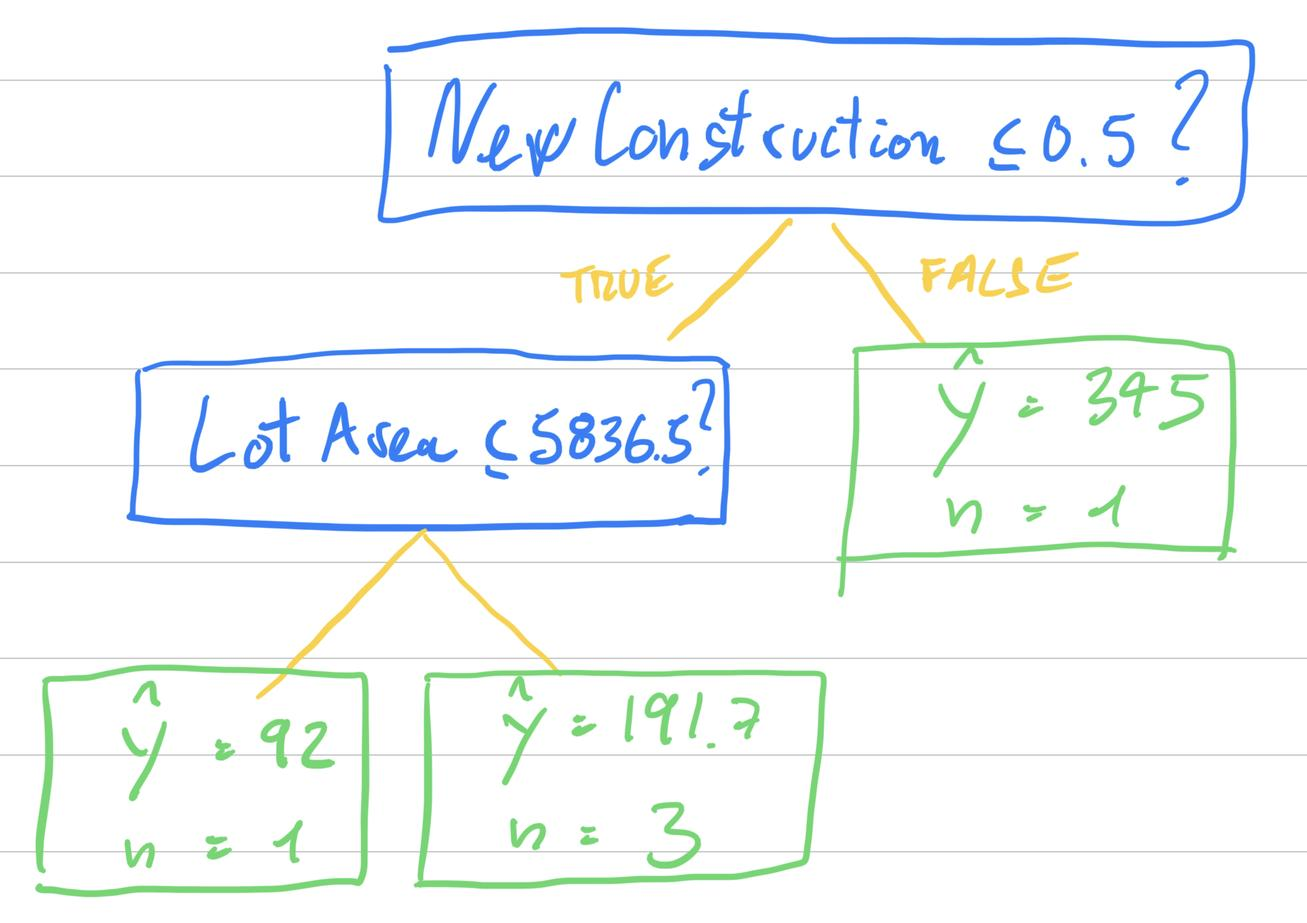

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    And now, since all leaf nodes contain less samples the the Minimum Samples Split number, our tree is complete! <br>
    In the next section we'll see how we'd do all this with just a few lines of code, with the help of scikit-learn.
</div>

<a id="6"></a>
# 💻 Code Implementation

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    sklearn's DecisionTreeRegressor will be doing all the heavy lifting, but now that we've seen how it works, we perhaps have a deeper appreciation of the open source community.
</div>

In [ ]:
# defining our tree object with the hyper parameters discussed above
model = DecisionTreeRegressor(
    criterion='squared_error',
    splitter='best',
    min_samples_split=4,
)

# CART algorithm that builds the tree based on our data
model.fit(
    X=df.drop(columns=['SalePrice']),
    y=df['SalePrice']
)

DecisionTreeRegressor(min_samples_split=4)

<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    sklearn's plot_tree comes in handy so that we can visualize our Decision Tree Regressor.
</div>

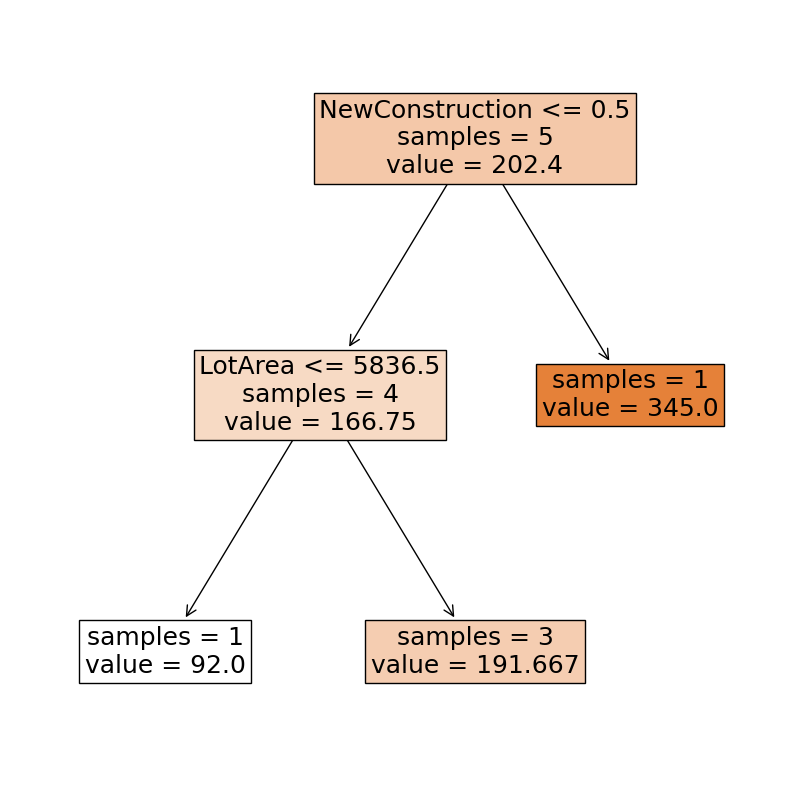

In [ ]:
plt.figure(figsize=(10, 10))
plot_tree(
    model,
    feature_names=['NewConstruction', 'Pool', 'LotArea'],
    impurity=False,
    filled=True,
    fontsize=18
)
plt.show()

In [ ]:
inputs = pd.DataFrame([{"NewConstruction": 0, "Pool": 1, "LotArea": 7000}])
prediction = model.predict(inputs)
print(f"Predicted SalePrice: {prediction}")

Predicted SalePrice: [191.66666667]


<div
     style="padding: 20px;
            color: #3b3b3b;
            font-size: 115%;
            text-align: left;
            display: fill;
            border-radius: 5px;
            background-color: #d7ffd7;
            overflow: hidden;
            font-weight: 600;
            border: 5px solid #ffcfa0;"
     >
    And now for Step 3, our final step in our first iteration, we split the data according to the best split, thereby creating 2 new nodes, in which we can repeat the CART steps.
</div>